## Importações e Configuração

In [31]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


## Carregamento dos Dados

Vamos carregar:
- **Dados de treino (baseline)**: dataset original usado para treinar o modelo
- **Dados de produção**: requisições reais com drift progressivo

In [32]:
# Carregar dados de treino (baseline) - dataset ORIGINAL
train_data = pd.read_csv('../data/heart_disease_uci.csv')

# Remover coluna 'dataset' se existir (metadata)
if 'dataset' in train_data.columns:
    train_data = train_data.drop(columns=['dataset'])

# Selecionar features (todas exceto target e id)
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
train_features = train_data[feature_cols].copy()

print(f"Dados de treino: {train_features.shape[0]} amostras, {train_features.shape[1]} features")
print(f"\nFeatures disponíveis: {feature_cols}")
print(f"\nPrimeiras linhas:")
train_features.head()

Dados de treino: 920 amostras, 13 features

Features disponíveis: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Primeiras linhas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [33]:
# Carregar logs de requisições (produção)
with open('flask-app/requests.log', 'r') as f:
    logs = [json.loads(line) for line in f]

print(f"Total de requisições logadas: {len(logs)}")
print(f"\nExemplo de log:")
logs[0]

Total de requisições logadas: 100

Exemplo de log:


{'timestamp': '2025-11-20T20:50:04.701834Z',
 'request_id': '3d6b837f-f629-4875-b88a-fa81dc230a54',
 'request_payload': '{"age": 59, "sex": 1, "cp": 2, "trestbps": 128, "chol": 298, "fbs": 0, "restecg": 0, "thalch": 179, "exang": 1, "oldpeak": 0.5, "slope": 2, "ca": 0, "thal": 1}',
 'response_payload': {'predictions': [0],
  'probabilities': [0.4398213457689265]},
 'status_code': 200,
 'latency_ms': 9.423}

In [34]:
# Extrair payloads e criar DataFrame de produção
production_records = []

for log in logs:
    try:
        # Parse do request_payload (pode estar como string JSON)
        if isinstance(log['request_payload'], str):
            payload = json.loads(log['request_payload'])
        else:
            payload = log['request_payload']
        
        # Adicionar metadados
        record = payload.copy()
        record['timestamp'] = log['timestamp']
        record['latency_ms'] = log['latency_ms']
        record['status_code'] = log['status_code']
        
        # Extrair predição se disponível
        if log['response_payload'] and 'predictions' in log['response_payload']:
            record['prediction'] = log['response_payload']['predictions'][0]
            if 'probabilities' in log['response_payload']:
                record['probability'] = log['response_payload']['probabilities'][0]
        
        production_records.append(record)
    except Exception as e:
        print(f"Erro ao processar log: {e}")
        continue

production_data = pd.DataFrame(production_records)
production_data['timestamp'] = pd.to_datetime(production_data['timestamp'])
production_data['request_num'] = range(1, len(production_data) + 1)

print(f"Dados de produção: {production_data.shape[0]} requisições processadas")
print(f"\nPrimeiras requisições:")
production_data.head()

Dados de produção: 100 requisições processadas

Primeiras requisições:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,timestamp,latency_ms,status_code,prediction,probability,request_num
0,59,1,2,128,298,0,0,179,1,0.5,2,0,1,2025-11-20 20:50:04.701834+00:00,9.423,200,0,0.439821,1
1,50,0,2,121,200,0,0,144,0,0.0,1,0,2,2025-11-20 20:50:04.766333+00:00,7.463,200,0,0.404220,2
2,54,1,3,120,200,0,0,140,0,0.0,2,0,1,2025-11-20 20:50:04.827215+00:00,8.833,200,0,0.378669,3
3,58,1,1,132,200,0,1,159,1,0.0,2,0,2,2025-11-20 20:50:04.893502+00:00,9.643,200,1,0.526488,4
4,62,0,1,136,200,0,1,128,0,0.0,2,1,2,2025-11-20 20:50:04.960564+00:00,10.091,200,1,0.516769,5


In [35]:
# Extrair apenas as features para análise de drift
production_features = production_data[feature_cols].copy()

print(f"Dados de produção: {len(production_features)} requisições")
print(f"\nComparação:")
print(f"  • Treino (baseline):  {len(train_features)} amostras")
print(f"  • Produção (drift):   {len(production_features)} requisições")

Dados de produção: 100 requisições

Comparação:
  • Treino (baseline):  920 amostras
  • Produção (drift):   100 requisições


## Análise Exploratória: Comparação de Distribuições

Vamos visualizar como as distribuições de features mudaram entre treino (baseline) e produção (com drift).

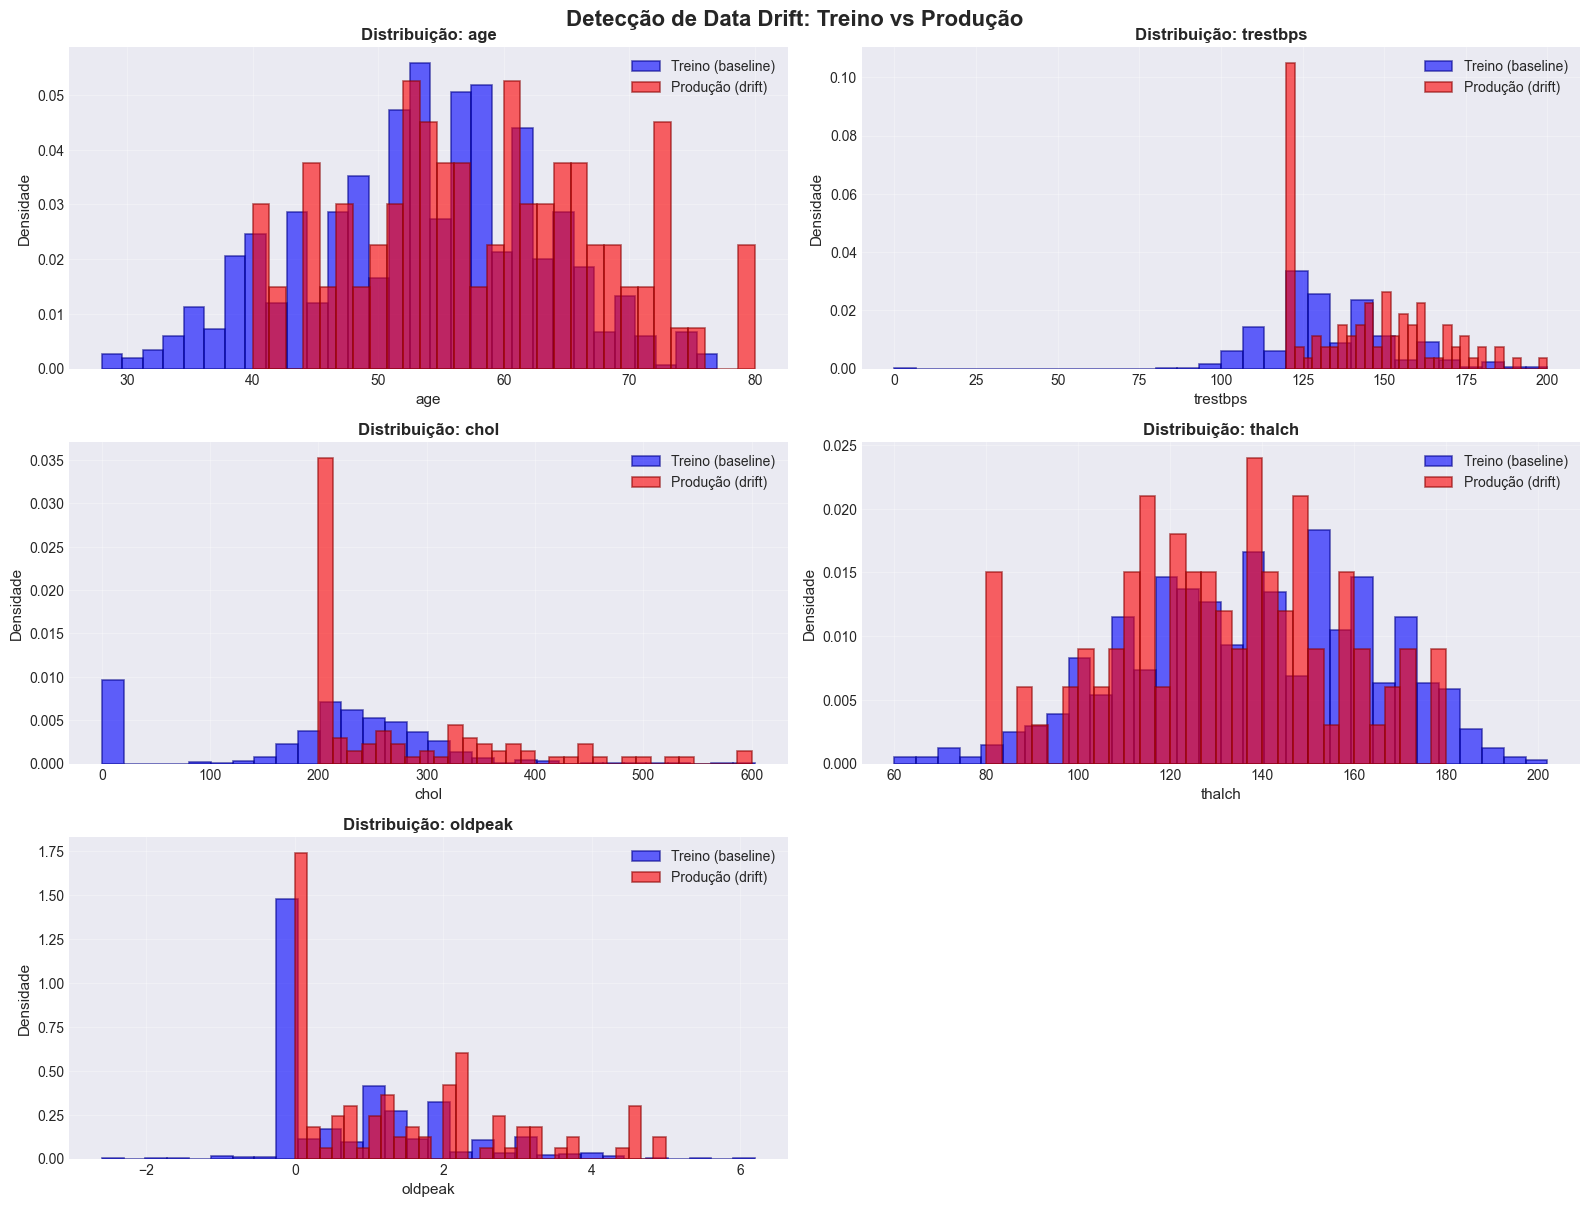

📊 Observe como as distribuições em VERMELHO (produção) divergem das AZUIS (treino)


In [36]:
# Features numéricas contínuas para análise detalhada
continuous_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(continuous_features):
    ax = axes[idx]
    
    # Histogramas sobrepostos: Treino (azul) vs Produção (vermelho)
    ax.hist(train_features[feature], bins=30, alpha=0.6, label='Treino (baseline)', 
            color='blue', density=True, edgecolor='darkblue', linewidth=1.2)
    ax.hist(production_features[feature], bins=30, alpha=0.6, label='Produção (drift)', 
            color='red', density=True, edgecolor='darkred', linewidth=1.2)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Densidade', fontsize=11)
    ax.set_title(f'Distribuição: {feature}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# Remover subplot extra
fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle('Detecção de Data Drift: Treino vs Produção', 
             fontsize=16, y=1.002, fontweight='bold')
plt.show()

print("📊 Observe como as distribuições em VERMELHO (produção) divergem das AZUIS (treino)")

## 4. Estatísticas Descritivas: Detecção de Mudanças

In [37]:
# Comparar estatísticas descritivas: Treino vs Produção
def compare_statistics(feature):
    stats_dict = {
        'Treino (baseline)': {
            'Média': train_features[feature].mean(),
            'Mediana': train_features[feature].median(),
            'Desvio Padrão': train_features[feature].std(),
            'Mín': train_features[feature].min(),
            'Máx': train_features[feature].max()
        },
        'Produção (drift)': {
            'Média': production_features[feature].mean(),
            'Mediana': production_features[feature].median(),
            'Desvio Padrão': production_features[feature].std(),
            'Mín': production_features[feature].min(),
            'Máx': production_features[feature].max()
        }
    }
    df_stats = pd.DataFrame(stats_dict).T
    # Adicionar coluna de diferença
    df_stats['Δ Média'] = df_stats['Média'] - df_stats.loc['Treino (baseline)', 'Média']
    return df_stats

print("="*80)
print("COMPARAÇÃO ESTATÍSTICA: TREINO vs PRODUÇÃO")
print("="*80)

for feature in ['age', 'trestbps', 'chol', 'thalch']:
    print(f"\n📈 {feature.upper()}")
    print("-"*80)
    display(compare_statistics(feature).round(2))

COMPARAÇÃO ESTATÍSTICA: TREINO vs PRODUÇÃO

📈 AGE
--------------------------------------------------------------------------------


,Média,Mediana,Desvio Padrão,Mín,Máx,Δ Média
Treino (baseline),53.51,54.0,9.42,28.0,77.0,0.00
Produção (drift),58.29,58.0,9.83,40.0,80.0,4.78



📈 TRESTBPS
--------------------------------------------------------------------------------


,Média,Mediana,Desvio Padrão,Mín,Máx,Δ Média
Treino (baseline),132.13,130.0,19.07,0.0,200.0,0.00
Produção (drift),144.17,144.0,20.73,120.0,200.0,12.04



📈 CHOL
--------------------------------------------------------------------------------


,Média,Mediana,Desvio Padrão,Mín,Máx,Δ Média
Treino (baseline),199.13,223.0,110.78,0.0,603.0,0.00
Produção (drift),277.22,219.0,101.55,200.0,600.0,78.09



📈 THALCH
--------------------------------------------------------------------------------


,Média,Mediana,Desvio Padrão,Mín,Máx,Δ Média
Treino (baseline),137.55,140.0,25.93,60.0,202.0,0.00
Produção (drift),130.88,132.0,24.35,80.0,180.0,-6.67


## Population Stability Index (PSI)

PSI quantifica a mudança na distribuição de uma feature:
- **PSI < 0.1**: sem mudança significativa (OK)
- **0.1 ≤ PSI < 0.2**: mudança menor (monitorar de perto)
- **PSI ≥ 0.2**: mudança significativa (retreinamento recomendado)

In [38]:
def calculate_psi(reference, current, bins=10):
    """
    Calcula o Population Stability Index (PSI).
    
    PSI = Σ (actual% - expected%) * ln(actual% / expected%)
    """
    # Criar bins baseados na distribuição de referência
    breakpoints = np.percentile(reference, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)  # Remover duplicatas
    
    # Calcular proporções em cada bin
    expected_percents = np.histogram(reference, bins=breakpoints)[0] / len(reference)
    actual_percents = np.histogram(current, bins=breakpoints)[0] / len(current)
    
    # Evitar divisão por zero
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    # Calcular PSI
    psi_values = (actual_percents - expected_percents) * np.log(actual_percents / expected_percents)
    psi = np.sum(psi_values)
    
    return psi

# Calcular PSI: Treino vs Produção
psi_results = []

for feature in continuous_features:
    psi_value = calculate_psi(
        train_features[feature].values,
        production_features[feature].values
    )
    
    # Classificação do drift
    if psi_value < 0.1:
        severity = 'OK ✓'
        color_indicator = '🟢'
    elif psi_value < 0.2:
        severity = 'Monitorar ⚠️'
        color_indicator = '🟡'
    else:
        severity = 'Retreinar 🔴'
        color_indicator = '🔴'
    
    psi_results.append({
        'Feature': feature,
        'PSI': psi_value,
        'Severidade': severity,
        '': color_indicator
    })

psi_df = pd.DataFrame(psi_results)

print("="*100)
print("POPULATION STABILITY INDEX (PSI): TREINO vs PRODUÇÃO")
print("="*100)
print("\n💡 PSI < 0.1: OK | 0.1-0.2: Monitorar | ≥ 0.2: Retreinar\n")
display(psi_df.round(4))

POPULATION STABILITY INDEX (PSI): TREINO vs PRODUÇÃO

💡 PSI < 0.1: OK | 0.1-0.2: Monitorar | ≥ 0.2: Retreinar



,Feature,PSI,Severidade,
0,age,0.7233,Retreinar 🔴,🔴
1,trestbps,0.0000,OK ✓,🟢
2,chol,0.0000,OK ✓,🟢
3,thalch,0.0000,OK ✓,🟢
4,oldpeak,0.0000,OK ✓,🟢
